# 03 · Fırsat puanı ve önerilen alternatif

Her ilçeye 0-100 arası bir **paylaşımlı ulaşım fırsat puanı** veriyoruz ve ilçeye uygun **alternatif türünü** belirliyoruz.

## Puanın bileşenleri

| Bileşen | Ölçüt | Ağırlık | Neden |
|---|---|---|---|
| Talep | 15-64 yaş nüfus (%70) + abonman payı (%30) | %30 | Potansiyel müşteri sayısı ve düzenli işe gidip gelme |
| Erişim açığı | Durakların istasyona 1 km'den uzak payı | %30 | Toplu taşımanın "ilk/son km" sorunu |
| Konfor açığı | Zirve saat otobüs yükü | %25 | Dolu otobüs = alternatife geçme isteği |
| Kupon duyarlılığı | Bin kişide sosyal yardım alan hane | %15 | Fiyata duyarlı kitle, indirimin etkisi büyük |

Her ölçüt 0-100 aralığına **min-max** ile ölçeklenir. Kırsal ilçeler (Silivri, Şile, Çatalca) ve Adalar kapsam dışı.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30, "display.width", 160)

from db import baglan, sorgu
from gorsel import *
stil_uygula()
con = baglan()

# İlçe kodlarını (ör. "EYUPSULTAN") grafiklerde düzgün Türkçe adla göstermek için
import geopandas as gpd
from utils import PROCESSED
ilceler = gpd.read_parquet(PROCESSED / "referans" / "ilceler.parquet")
AD = dict(zip(ilceler["ilce"], ilceler["ilce_adi"]))
import numpy as np

m = pd.read_csv(PROCESSED / "ilce_metrikleri.csv")
m["ad"] = m["ilce"].map(AD)

In [2]:
def olcekle(s: pd.Series) -> pd.Series:
    """Min-max ölçekleme: en düşük ilçe 0, en yüksek 100."""
    return (s - s.min()) / (s.max() - s.min()) * 100

bilesen = pd.DataFrame({
    "ilce": m["ilce"],
    "talep": 0.7 * olcekle(m["nufus_15_64"]) + 0.3 * olcekle(m["abonman_payi"]),
    "erisim_acigi": olcekle(m["uzak_durak_payi"]),
    "konfor_acigi": olcekle(m["zirve_otobus_yuku"]),
    "kupon_duyarliligi": olcekle(m["sosyal_yardim_binde"]),
})
AGIRLIK = {"talep": 0.30, "erisim_acigi": 0.30, "konfor_acigi": 0.25, "kupon_duyarliligi": 0.15}

def puanla(b: pd.DataFrame, w: dict) -> pd.Series:
    return sum(b[k] * v for k, v in w.items())

bilesen["firsat_puani"] = puanla(bilesen, AGIRLIK)
sonuc = m.merge(bilesen, on="ilce").sort_values("firsat_puani", ascending=False).reset_index(drop=True)
sonuc.index += 1
sonuc[["ad", "firsat_puani", "talep", "erisim_acigi", "konfor_acigi", "kupon_duyarliligi"]].round(1).head(15)

,ad,firsat_puani,talep,erisim_acigi,konfor_acigi,kupon_duyarliligi
1,Sultanbeyli,78.7,40.8,100.0,85.9,100.0
2,Sancaktepe,77.9,54.0,98.1,88.4,68.0
3,Küçükçekmece,68.1,70.1,67.3,82.1,42.2
4,Esenyurt,66.4,74.8,79.5,45.4,58.7
5,Sultangazi,65.1,47.1,64.1,83.2,72.9
6,Çekmeköy,65.1,35.1,93.4,83.3,38.0
7,Ümraniye,64.6,71.4,48.0,94.0,35.3
8,Bahçelievler,62.7,45.9,61.5,95.0,44.6
9,Başakşehir,58.5,41.7,58.9,95.3,30.0
10,Beykoz,58.4,34.4,100.0,57.4,24.8


## 1. Puanın kırılımı: ilk 10 ilçe neden üstte?

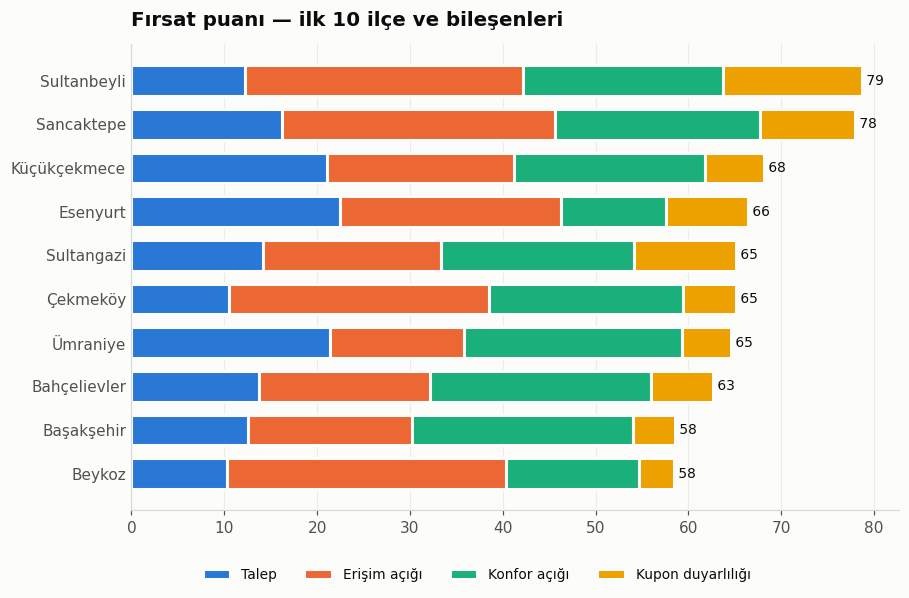

In [3]:
ilk10 = sonuc.head(10).iloc[::-1]
parcalar = [("talep", "Talep", MAVI), ("erisim_acigi", "Erişim açığı", TURUNCU),
            ("konfor_acigi", "Konfor açığı", CAMGOBEGI), ("kupon_duyarliligi", "Kupon duyarlılığı", "#eda100")]
fig, ax = plt.subplots(figsize=(9, 5.5))
sol = np.zeros(len(ilk10))
for kol, etiket, renk in parcalar:
    deger = ilk10[kol] * AGIRLIK[kol]
    ax.barh(ilk10["ad"], deger, left=sol, color=renk, label=etiket, height=0.7,
            edgecolor=ZEMIN, linewidth=2)
    sol += deger
for y, v in enumerate(sol):
    ax.text(v, y, f" {v:.0f}", va="center", fontsize=9, color=YAZI)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.tick_params(axis="y", length=0)
ax.legend(loc="lower center", bbox_to_anchor=(0.45, -0.18), ncol=4, fontsize=9)
ax.set_title("Fırsat puanı — ilk 10 ilçe ve bileşenleri")
kaydet(fig, "03_firsat_puani")

## 2. Duyarlılık analizi: ağırlıkları değiştirince sonuç değişiyor mu?

Ağırlıkları biz seçtik, bu yüzden sonucun bu seçime ne kadar bağlı olduğunu test etmeliyiz.
**5.000 kez rastgele ağırlık** üretiyoruz (her biri bizim ağırlıklarımızın etrafında dağılıyor) ve
her ilçenin **ilk 10'a kaç kez girdiğini** sayıyoruz.

In [4]:
rng = np.random.default_rng(42)
w0 = np.array(list(AGIRLIK.values()))
B = bilesen[list(AGIRLIK)].to_numpy()

ilk10_sayac = pd.Series(0, index=bilesen["ilce"])
siralar = []
for w in rng.dirichlet(w0 * 20, size=5000):     # ortalaması w0 olan rastgele ağırlıklar
    p = B @ w
    sira = pd.Series(p, index=bilesen["ilce"]).rank(ascending=False)
    siralar.append(sira)
    ilk10_sayac[sira <= 10] += 1

dayaniklilik = (ilk10_sayac / 5000 * 100).rename("ilk10_yuzde")
medyan_sira = pd.concat(siralar, axis=1).median(axis=1).rename("medyan_sira")
sonuc = sonuc.merge(dayaniklilik, left_on="ilce", right_index=True).merge(medyan_sira, left_on="ilce", right_index=True)
sonuc.index = range(1, len(sonuc) + 1)
sonuc[["ad", "firsat_puani", "ilk10_yuzde", "medyan_sira"]].head(14).round(1)

,ad,firsat_puani,ilk10_yuzde,medyan_sira
1,Sultanbeyli,78.7,100.0,1.0
2,Sancaktepe,77.9,100.0,2.0
3,Küçükçekmece,68.1,100.0,4.0
4,Esenyurt,66.4,94.6,5.0
5,Sultangazi,65.1,99.8,6.0
6,Çekmeköy,65.1,97.0,6.0
7,Ümraniye,64.6,94.9,6.0
8,Bahçelievler,62.7,98.5,7.0
9,Başakşehir,58.5,65.6,10.0
10,Beykoz,58.4,63.5,10.0


**Yorum:** İlk 8 ilçe 5.000 farklı ağırlık denemesinin **en az %94'ünde** ilk 10'da kalıyor.
Yani sonuç tek bir ağırlık seçimine bağlı **keyfi bir sıralama değil**. 9. ve 10. sıradaki Başakşehir ve Beykoz ise
denemelerin ~%65'inde ilk 10'da; bunlar "ikinci dalga" adayı olarak değerlendirilmeli.

## 3. Hangi ilçeye hangi alternatif?

Basit ve açıklanabilir kurallar:

| Koşul | Öneri | Gerekçe |
|---|---|---|
| Zirve hız < 30 km/s | **Scooter / e-bisiklet** | Araç trafikte kalır; iki teker kalmaz |
| İstasyona medyan mesafe > 3 km | **Paylaşımlı araç / mikro-servis** | Scooter için mesafe uzun, istasyona "ring" gerekir |
| İstasyona medyan mesafe 0,8-3 km | **Scooter / e-bisiklet** | Klasik ilk/son km mesafesi |
| Diğer | **Düşük öncelik** | Toplu taşıma erişimi zaten iyi |

In [5]:
def alternatif(r) -> str:
    if r["zirve_hiz_kmh"] < 30:
        return "Scooter / e-bisiklet"
    if r["medyan_istasyon_mesafesi_m"] > 3000:
        return "Paylaşımlı araç / mikro-servis"
    if r["medyan_istasyon_mesafesi_m"] > 800:
        return "Scooter / e-bisiklet"
    return "Düşük öncelik"

sonuc["oneri"] = sonuc.apply(alternatif, axis=1)
tablo = sonuc[["ad", "firsat_puani", "ilk10_yuzde", "medyan_istasyon_mesafesi_m", "zirve_hiz_kmh",
               "zirve_otobus_yuku", "oneri"]].head(10).round({"firsat_puani": 1, "ilk10_yuzde": 0,
               "medyan_istasyon_mesafesi_m": -1, "zirve_hiz_kmh": 0, "zirve_otobus_yuku": 2})
tablo

,ad,firsat_puani,ilk10_yuzde,medyan_istasyon_mesafesi_m,zirve_hiz_kmh,zirve_otobus_yuku,oneri
1,Sultanbeyli,78.7,100.0,6390.0,53.0,1.30,Paylaşımlı araç / mikro-servis
2,Sancaktepe,77.9,100.0,5040.0,52.0,1.32,Paylaşımlı araç / mikro-servis
3,Küçükçekmece,68.1,100.0,1560.0,30.0,1.26,Scooter / e-bisiklet
4,Esenyurt,66.4,95.0,2470.0,42.0,0.95,Scooter / e-bisiklet
5,Sultangazi,65.1,100.0,1310.0,43.0,1.27,Scooter / e-bisiklet
6,Çekmeköy,65.1,97.0,4340.0,74.0,1.27,Paylaşımlı araç / mikro-servis
7,Ümraniye,64.6,95.0,970.0,32.0,1.37,Scooter / e-bisiklet
8,Bahçelievler,62.7,98.0,1330.0,28.0,1.38,Scooter / e-bisiklet
9,Başakşehir,58.5,66.0,1310.0,52.0,1.38,Scooter / e-bisiklet
10,Beykoz,58.4,63.0,6970.0,69.0,1.05,Paylaşımlı araç / mikro-servis


## 4. Harita

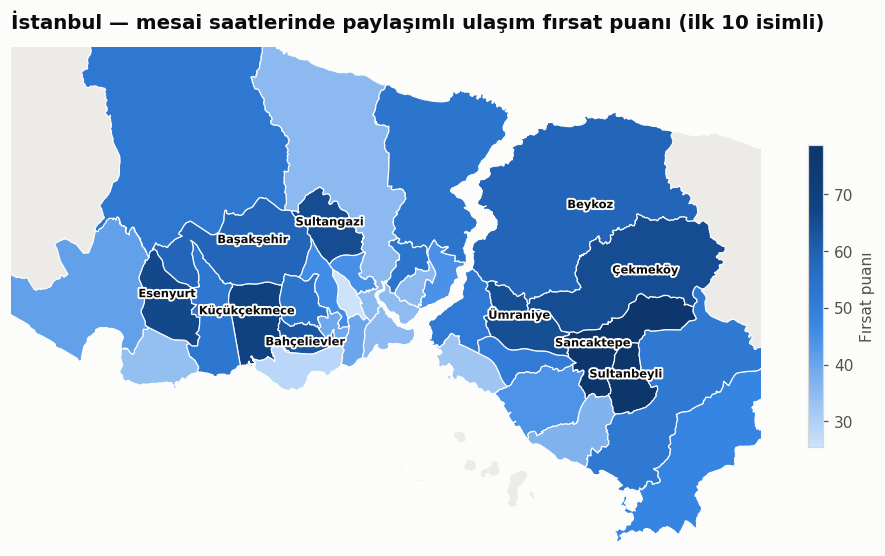

In [6]:
harita = ilceler.merge(sonuc[["ilce", "firsat_puani", "oneri"]], on="ilce", how="left")
fig, ax = plt.subplots(figsize=(11, 6.5))
harita[harita["firsat_puani"].isna()].plot(ax=ax, color="#ecebe8", edgecolor=ZEMIN, linewidth=0.6)
harita.dropna(subset=["firsat_puani"]).plot(ax=ax, column="firsat_puani", cmap=MAVI_SKALA,
    edgecolor=ZEMIN, linewidth=0.8, legend=True,
    legend_kwds={"shrink": 0.55, "label": "Fırsat puanı"})
import matplotlib.patheffects as pe
KAYDIR = {"BAHCELIEVLER": (2, -6), "KUCUKCEKMECE": (-6, 7)}   # üst üste binen etiketler
for _, r in harita[harita["ilce"].isin(sonuc.head(10)["ilce"])].iterrows():
    p = r.geometry.representative_point()
    ax.annotate(r["ilce_adi"], (p.x, p.y), xytext=KAYDIR.get(r["ilce"], (0, 0)), textcoords="offset points",
                ha="center", fontsize=7.5, color=YAZI, weight="bold",
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])
ax.set_xlim(28.45, 29.45); ax.set_ylim(40.80, 41.30)
ax.set_axis_off()
ax.set_title("İstanbul — mesai saatlerinde paylaşımlı ulaşım fırsat puanı (ilk 10 isimli)")
kaydet(fig, "03_firsat_haritasi")

In [7]:
import folium
fharita = folium.Map(location=[41.03, 28.98], zoom_start=10, tiles="cartodbpositron")
folium.Choropleth(
    geo_data=harita.dropna(subset=["firsat_puani"]).to_json(),
    data=sonuc, columns=["ilce", "firsat_puani"], key_on="feature.properties.ilce",
    fill_color="Blues", fill_opacity=0.75, line_opacity=0.4, legend_name="Fırsat puanı",
).add_to(fharita)
bilgi = harita.merge(sonuc[["ilce", "medyan_istasyon_mesafesi_m", "zirve_otobus_yuku", "zirve_hiz_kmh"]], on="ilce")
bilgi = bilgi.dropna(subset=["firsat_puani"]).round(1)
folium.GeoJson(
    bilgi.to_json(),
    style_function=lambda f: {"fillOpacity": 0, "weight": 0},
    tooltip=folium.GeoJsonTooltip(
        fields=["ilce_adi", "firsat_puani", "oneri", "medyan_istasyon_mesafesi_m", "zirve_otobus_yuku", "zirve_hiz_kmh"],
        aliases=["İlçe", "Fırsat puanı", "Öneri", "İstasyona medyan mesafe (m)", "Zirve otobüs yükü", "Zirve hız (km/s)"]),
).add_to(fharita)
fharita.save(IMAGES / "firsat_haritasi.html")
fharita

In [8]:
kayit = sonuc[["ilce", "ad", "firsat_puani", "talep", "erisim_acigi", "konfor_acigi", "kupon_duyarliligi",
               "ilk10_yuzde", "medyan_sira", "oneri", "zirve_binis", "nufus_15_64",
               "medyan_istasyon_mesafesi_m", "zirve_hiz_kmh", "zirve_otobus_yuku"]]
kayit.to_csv(PROCESSED / "firsat_puanlari.csv", index=False)
print("Kaydedildi -> data/processed/firsat_puanlari.csv")

Kaydedildi -> data/processed/firsat_puanlari.csv
